In [13]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
!pip install -q xgboost

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Attention,
    Concatenate
)

from tensorflow.keras.callbacks import EarlyStopping

from xgboost import XGBRegressor

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [16]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [17]:
import zipfile
import os

zip_name = list(uploaded.keys())[0]

extract_path = "/content/beijing_air_quality"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted.")

Dataset extracted.


In [19]:
for root, dirs, files_list in os.walk(extract_path):
    for file in files_list:
        print(os.path.join(root, file))

/content/beijing_air_quality/PRSA_Data_Dongsi_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Nongzhanguan_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Changping_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Wanliu_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Huairou_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Guanyuan_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Dingling_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Aotizhongxin_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Tiantan_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Gucheng_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Wanshouxigong_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Shunyi_20130301-20170228.csv


In [20]:
import glob

csv_files = glob.glob(
    extract_path + "/**/*.csv",
    recursive=True
)

print("Number of CSV files:", len(csv_files))

for file in csv_files:
    print(os.path.basename(file))

Number of CSV files: 12
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Nongzhanguan_20130301-20170228.csv
PRSA_Data_Changping_20130301-20170228.csv
PRSA_Data_Wanliu_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Guanyuan_20130301-20170228.csv
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Aotizhongxin_20130301-20170228.csv
PRSA_Data_Tiantan_20130301-20170228.csv
PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_Wanshouxigong_20130301-20170228.csv
PRSA_Data_Shunyi_20130301-20170228.csv


In [21]:
station_data = []

for file in csv_files:

    temp = pd.read_csv(file)

    station_data.append(temp)

df = pd.concat(
    station_data,
    ignore_index=True
)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [22]:
print(df.columns)

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')


In [23]:
df["datetime"] = pd.to_datetime(
    df[
        ["year", "month", "day", "hour"]
    ]
)

df = df.sort_values(
    ["station", "datetime"]
)

display(
    df[
        ["station", "datetime", "PM2.5"]
    ].head()
)

,station,datetime,PM2.5
245448,Aotizhongxin,2013-03-01 00:00:00,4.0
245449,Aotizhongxin,2013-03-01 01:00:00,8.0
245450,Aotizhongxin,2013-03-01 02:00:00,7.0
245451,Aotizhongxin,2013-03-01 03:00:00,6.0
245452,Aotizhongxin,2013-03-01 04:00:00,3.0


In [24]:
print(
    df["station"].unique()
)

print(
    "Number of stations:",
    df["station"].nunique()
)

['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhanguan' 'Shunyi' 'Tiantan' 'Wanliu' 'Wanshouxigong']
Number of stations: 12


In [25]:
missing = df.isnull().sum()

missing = missing[
    missing > 0
].sort_values(
    ascending=False
)

display(missing)

,0
CO,20701
O3,13277
NO2,12116
SO2,9021
PM2.5,8739
PM10,6449
wd,1822
DEWP,403
TEMP,398
PRES,393


In [26]:
numeric_cols = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

for col in numeric_cols:

    df[col] = (
        df.groupby("station")[col]
        .transform(
            lambda x:
            x.interpolate(
                method="linear"
            )
        )
    )

    df[col] = (
        df.groupby("station")[col]
        .transform(
            lambda x:
            x.ffill().bfill()
        )
    )

In [27]:
print(
    df[numeric_cols].isnull().sum()
)

PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


In [28]:
df["wd"] = (
    df["wd"]
    .astype("category")
    .cat.codes
)

In [29]:
print(
    sorted(df["station"].unique())
)

['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


In [30]:
TARGET_STATION = "Tiantan"

station_df = df[
    df["station"] == TARGET_STATION
].copy()

station_df = station_df.sort_values(
    "datetime"
)

print(
    station_df.shape
)

display(
    station_df.head()
)

(35064, 19)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
280512,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,6,5.7,Tiantan,2013-03-01 00:00:00
280513,2,2013,3,1,1,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,7,3.9,Tiantan,2013-03-01 01:00:00
280514,3,2013,3,1,2,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,6,5.3,Tiantan,2013-03-01 02:00:00
280515,4,2013,3,1,3,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,3,4.9,Tiantan,2013-03-01 03:00:00
280516,5,2013,3,1,4,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,6,3.2,Tiantan,2013-03-01 04:00:00


In [31]:
all_stations = sorted(
    df["station"].unique()
)

neighbor_stations = [
    s for s in all_stations
    if s != TARGET_STATION
][:3]

print(
    "Target station:",
    TARGET_STATION
)

print(
    "Neighbor stations:",
    neighbor_stations
)

Target station: Tiantan
Neighbor stations: ['Aotizhongxin', 'Changping', 'Dingling']


In [32]:
target_scaler = MinMaxScaler()

station_df["PM25_scaled"] = (
    target_scaler.fit_transform(
        station_df[["PM2.5"]]
    )
)

In [33]:
split = int(
    len(station_df) * 0.80
)

train_df = station_df.iloc[
    :split
].copy()

test_df = station_df.iloc[
    split:
].copy()

print(
    "Train:",
    len(train_df)
)

print(
    "Test:",
    len(test_df)
)

Train: 28051
Test: 7013


In [35]:
LOOKBACK = 48

def create_sequences(
    data,
    lookback=48
):

    X = []
    y = []

    for i in range(
        lookback,
        len(data)
    ):

        X.append(
            data[
                i-lookback:i
            ]
        )

        y.append(
            data[i]
        )

    return (
        np.array(X),
        np.array(y)
    )

In [36]:
X_train_single, y_train_single = create_sequences(
    train_df["PM25_scaled"].values,
    LOOKBACK
)

X_test_single, y_test_single = create_sequences(
    test_df["PM25_scaled"].values,
    LOOKBACK
)

X_train_single = X_train_single.reshape(
    X_train_single.shape[0],
    X_train_single.shape[1],
    1
)

X_test_single = X_test_single.reshape(
    X_test_single.shape[0],
    X_test_single.shape[1],
    1
)

print(
    X_train_single.shape,
    y_train_single.shape
)

(28003, 48, 1) (28003,)


In [37]:
def build_single_lstm():

    inputs = Input(
        shape=(48, 1)
    )

    x = LSTM(
        64,
        return_sequences=True
    )(inputs)

    x = LSTM(
        64
    )(x)

    output = Dense(
        1
    )(x)

    model = Model(
        inputs,
        output
    )

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [38]:
single_model = build_single_lstm()

single_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 48, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_single = single_model.fit(
    X_train_single,
    y_train_single,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0019 - val_loss: 7.4409e-04
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 6.5115e-04 - val_loss: 4.2033e-04
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5.5521e-04 - val_loss: 4.0257e-04
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5.5114e-04 - val_loss: 4.2914e-04
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5.4892e-04 - val_loss: 3.9701e-04
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5.3913e-04 - val_loss: 3.8866e-04
Epoch 7/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 5.4090e-04 - val_loss: 4.6388e-04
Epoch 8/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 5.4016e-04 - val_loss: 3.8824e-04
Epoch 9/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5.3752e-04 - val_loss: 4.2527e-04
Epoch 10/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 5.3978e-04 - val_loss: 4.0013e-04
Epoch 11/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss

In [43]:
single_prediction_scaled = (
    single_model.predict(
        X_test_single
    )
)

single_prediction = (
    target_scaler.inverse_transform(
        single_prediction_scaled
    )
    .flatten()
)

single_actual = (
    target_scaler.inverse_transform(
        y_test_single.reshape(-1, 1)
    )
    .flatten()
)

218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [44]:
target_data = df[
    df["station"] == TARGET_STATION
].copy()

target_data = target_data.sort_values(
    "datetime"
)

In [45]:
target_features = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

In [46]:
multi_df = target_data[
    ["datetime"] + target_features
].copy()

for station in neighbor_stations:

    temp = df[
        df["station"] == station
    ][
        ["datetime", "PM2.5"]
    ].copy()

    temp = temp.rename(
        columns={
            "PM2.5":
            f"{station}_PM25"
        }
    )

    multi_df = multi_df.merge(
        temp,
        on="datetime",
        how="left"
    )

In [47]:
display(
    multi_df.head()
)

print(
    multi_df.shape
)

print(
    multi_df.isnull().sum()
)

,datetime,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,Aotizhongxin_PM25,Changping_PM25,Dingling_PM25
0,2013-03-01 00:00:00,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,5.7,4.0,3.0,4.0
1,2013-03-01 01:00:00,6.0,29.0,5.0,9.0,300.0,80.0,-0.7,1025.1,-22.1,0.0,3.9,8.0,3.0,7.0
2,2013-03-01 02:00:00,6.0,6.0,4.0,12.0,300.0,75.0,-1.2,1025.3,-24.6,0.0,5.3,7.0,3.0,5.0
3,2013-03-01 03:00:00,6.0,6.0,4.0,12.0,300.0,74.0,-1.4,1026.2,-25.5,0.0,4.9,6.0,3.0,6.0
4,2013-03-01 04:00:00,5.0,5.0,7.0,15.0,400.0,70.0,-1.9,1027.1,-24.5,0.0,3.2,3.0,3.0,5.0


(35064, 15)
datetime             0
PM2.5                0
PM10                 0
SO2                  0
NO2                  0
CO                   0
O3                   0
TEMP                 0
PRES                 0
DEWP                 0
RAIN                 0
WSPM                 0
Aotizhongxin_PM25    0
Changping_PM25       0
Dingling_PM25        0
dtype: int64


In [49]:
multi_df = (
    multi_df
    .sort_values("datetime")
    .interpolate()
    .ffill()
    .bfill()
)

In [50]:
multi_features = (
    target_features +
    [
        f"{s}_PM25"
        for s in neighbor_stations
    ]
)

multi_scaler = MinMaxScaler()

multi_df[
    multi_features
] = multi_scaler.fit_transform(
    multi_df[multi_features]
)

In [51]:
def create_multivariate_sequences(
    df,
    features,
    target,
    lookback=48
):

    X = []
    y = []

    values = df[features].values
    target_values = df[target].values

    for i in range(
        lookback,
        len(df)
    ):

        X.append(
            values[
                i-lookback:i
            ]
        )

        y.append(
            target_values[i]
        )

    return (
        np.array(X),
        np.array(y)
    )

In [52]:
split = int(
    len(multi_df) * 0.80
)

multi_train = multi_df.iloc[
    :split
].copy()

multi_test = multi_df.iloc[
    split:
].copy()

In [53]:
X_train_multi, y_train_multi = (
    create_multivariate_sequences(
        multi_train,
        multi_features,
        "PM2.5",
        LOOKBACK
    )
)

X_test_multi, y_test_multi = (
    create_multivariate_sequences(
        multi_test,
        multi_features,
        "PM2.5",
        LOOKBACK
    )
)

print(
    X_train_multi.shape
)

print(
    y_train_multi.shape
)

(28003, 48, 14)
(28003,)


In [54]:
def build_attention_lstm(
    n_features
):

    inputs = Input(
        shape=(48, n_features)
    )

    # Encoder
    encoder = LSTM(
        64,
        return_sequences=True
    )(inputs)

    encoder = LSTM(
        64,
        return_sequences=True
    )(encoder)

    # Attention
    attention = Attention()(
        [encoder, encoder]
    )

    combined = Concatenate()(
        [encoder, attention]
    )

    # Final LSTM
    x = LSTM(
        64
    )(combined)

    output = Dense(
        1
    )(x)

    model = Model(
        inputs,
        output
    )

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model

In [55]:
multi_model = build_attention_lstm(
    len(multi_features)
)

multi_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 48, 64)    │     20,224 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 48, 64)    │     33,024 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 48, 64)    │          0 │ lstm_3[0][0],     │
│ (Attention)         │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48, 128)   │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 64)        │     49,408 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ lstm_4[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 102,721 (401.25 KB)

 Trainable params: 102,721 (401.25 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
history_multi = multi_model.fit(
    X_train_multi,
    y_train_multi,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0023 - val_loss: 6.9924e-04
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.6705e-04 - val_loss: 3.8317e-04
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5.4474e-04 - val_loss: 4.1137e-04
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4.8619e-04 - val_loss: 3.9080e-04
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4.7867e-04 - val_loss: 3.2783e-04
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4.4908e-04 - val_loss: 3.2269e-04
Epoch 7/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4.5878e-04 - val_loss: 3.2737e-04
Epoch 8/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4.4384e-04 - val_loss: 3.1142e-04
Epoch 9/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 4.4819e-04 - val_loss: 3.6503e-04
Epoch 10/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4.2872e-04 - val_loss: 3.0710e-04
Epoch 11/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step

In [57]:
multi_prediction_scaled = (
    multi_model.predict(
        X_test_multi
    )
)

218/218 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [59]:
target_index = multi_features.index(
    "PM2.5"
)

temp = np.zeros(
    (
        len(multi_prediction_scaled),
        len(multi_features)
    )
)

temp[:, target_index] = (
    multi_prediction_scaled.flatten()
)

multi_prediction_original = (
    multi_scaler.inverse_transform(
        temp
    )[:, target_index]
)

In [61]:
temp_actual = np.zeros(
    (
        len(y_test_multi),
        len(multi_features)
    )
)

temp_actual[:, target_index] = (
    y_test_multi
)

multi_actual = (
    multi_scaler.inverse_transform(
        temp_actual
    )[:, target_index]
)

In [62]:
n = min(
    len(single_prediction),
    len(multi_prediction_original)
)

single_p = single_prediction[:n]

multi_p = (
    multi_prediction_original[:n]
)

actual = multi_actual[:n]

In [63]:
xgb_df = pd.DataFrame({

    "single_factor_prediction":
        single_p,

    "multi_factor_prediction":
        multi_p
})

In [64]:
weather_cols = [
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

In [65]:
weather_test = (
    multi_test[
        weather_cols
    ]
    .iloc[
        LOOKBACK:
    ]
    .reset_index(drop=True)
)

weather_test = weather_test.iloc[
    :n
]

In [66]:
xgb_df = pd.concat(
    [
        xgb_df.reset_index(drop=True),
        weather_test.reset_index(drop=True)
    ],
    axis=1
)

display(
    xgb_df.head()
)

,single_factor_prediction,multi_factor_prediction,TEMP,PRES,DEWP,RAIN,WSPM
0,43.322556,43.045453,0.528497,0.426230,0.726989,0.0,0.114286
1,39.449318,40.400998,0.523316,0.431694,0.725429,0.0,0.104762
2,42.158272,40.582522,0.521589,0.442623,0.723869,0.0,0.104762
3,48.510281,43.737138,0.523316,0.438980,0.728549,0.0,0.104762
4,53.249161,52.337193,0.526770,0.437158,0.731669,0.0,0.095238


In [67]:
xgb_split = int(
    len(xgb_df) * 0.8
)

X_xgb_train = xgb_df.iloc[
    :xgb_split
]

X_xgb_test = xgb_df.iloc[
    xgb_split:
]

y_xgb_train = actual[
    :xgb_split
]

y_xgb_test = actual[
    xgb_split:
]

In [68]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(
    X_xgb_train,
    y_xgb_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [69]:
final_prediction = (
    xgb_model.predict(
        X_xgb_test
    )
)

final_actual = y_xgb_test

In [71]:
def calculate_metrics(
    actual,
    predicted
):

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    mape = np.mean(
        np.abs(
            (
                actual -
                predicted
            ) /
            np.where(
                actual == 0,
                1e-8,
                actual
            )
        )
    ) * 100

    r2 = r2_score(
        actual,
        predicted
    )

    mean_actual = np.mean(actual)

    ia_numerator = np.sum(
        (
            predicted -
            actual
        ) ** 2
    )

    ia_denominator = np.sum(
        (
            np.abs(
                predicted -
                mean_actual
            ) +
            np.abs(
                actual -
                mean_actual
            )
        ) ** 2
    )

    ia = (
        1 -
        ia_numerator /
        ia_denominator
    )

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "R2": r2,
        "IA": ia
    }

In [72]:
final_metrics = calculate_metrics(
    final_actual,
    final_prediction
)

results = pd.DataFrame(
    [final_metrics]
)

display(
    results.round(4)
)

,RMSE,MAE,MAPE (%),R2,IA
0,26.7821,13.0445,45.296,0.9392,0.9833


In [73]:
single_metrics = calculate_metrics(
    single_actual[:n],
    single_p
)

multi_metrics = calculate_metrics(
    multi_actual[:n],
    multi_p
)

final_metrics = calculate_metrics(
    final_actual,
    final_prediction
)

In [74]:
comparison = pd.DataFrame(
    [
        single_metrics,
        multi_metrics,
        final_metrics
    ],
    index=[
        "Single-Factor LSTM",
        "Attention Multi-Factor LSTM",
        "Integrated Dual LSTM + XGBoost"
    ]
)

display(
    comparison.round(4)
)

,RMSE,MAE,MAPE (%),R2,IA
Single-Factor LSTM,17.9410,10.3704,34.5601,0.9551,0.9882
Attention Multi-Factor LSTM,16.1408,9.8941,28.7449,0.9636,0.9908
Integrated Dual LSTM + XGBoost,26.7821,13.0445,45.2960,0.9392,0.9833


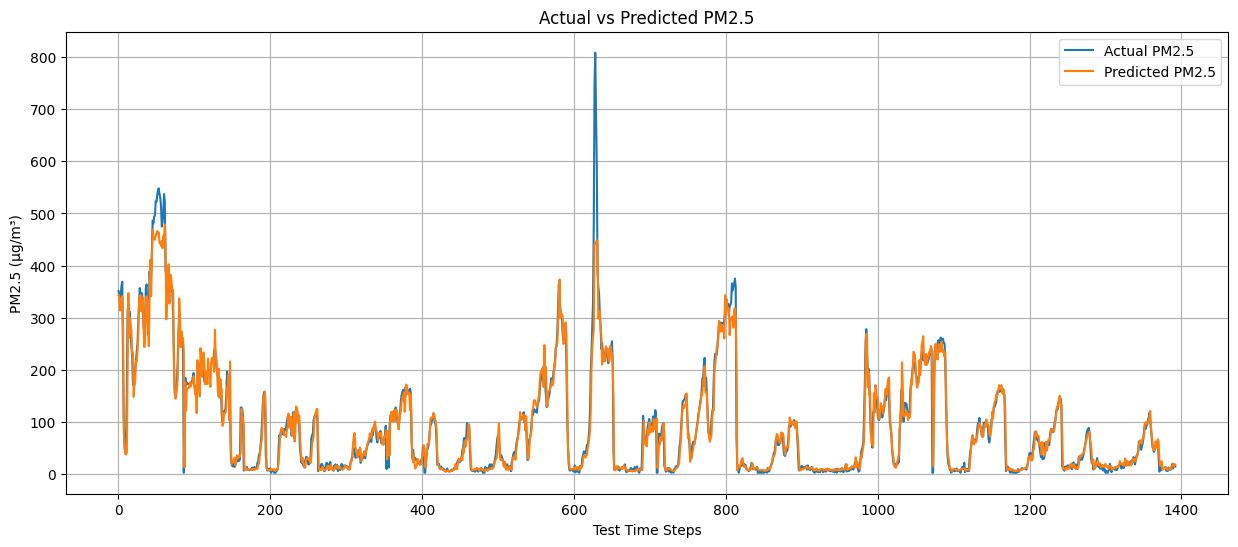

In [75]:
plt.figure(
    figsize=(15, 6)
)

plt.plot(
    final_actual,
    label="Actual PM2.5"
)

plt.plot(
    final_prediction,
    label="Predicted PM2.5"
)

plt.xlabel(
    "Test Time Steps"
)

plt.ylabel(
    "PM2.5 (µg/m³)"
)

plt.title(
    "Actual vs Predicted PM2.5"
)

plt.legend()

plt.grid()

plt.show()

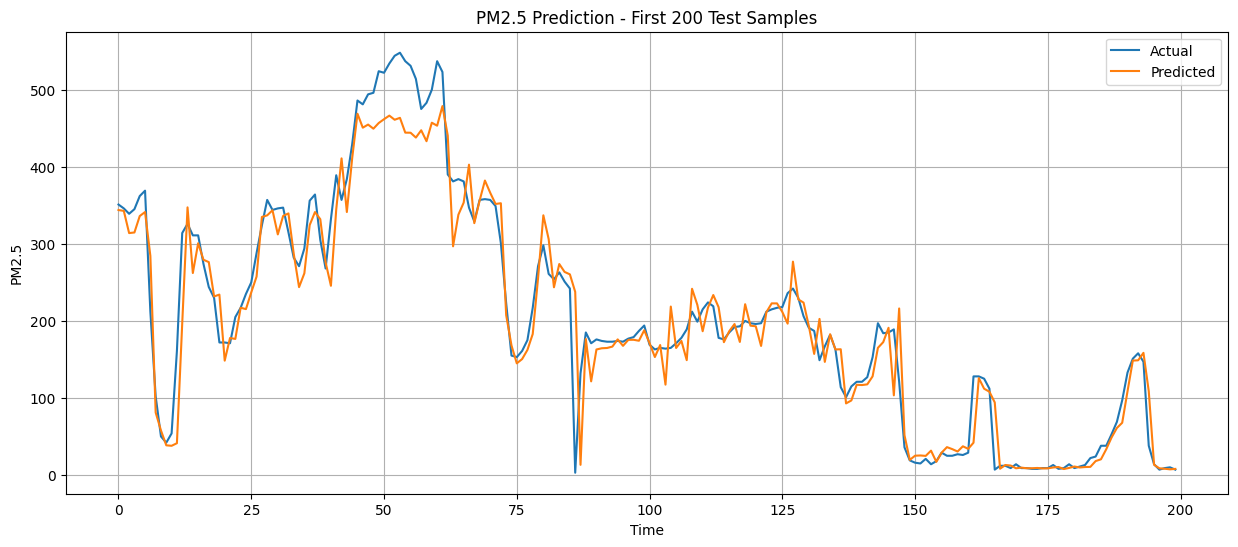

In [76]:
N = 200

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    final_actual[:N],
    label="Actual"
)

plt.plot(
    final_prediction[:N],
    label="Predicted"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "PM2.5"
)

plt.title(
    "PM2.5 Prediction - First 200 Test Samples"
)

plt.legend()

plt.grid()

plt.show()

In [77]:
prediction_df = pd.DataFrame({

    "Actual_PM2.5":
        final_actual,

    "Predicted_PM2.5":
        final_prediction,

    "Error":
        final_actual -
        final_prediction
})

prediction_df.to_csv(
    "PM25_Final_Predictions.csv",
    index=False
)

print(
    "Prediction CSV saved."
)

Prediction CSV saved.


In [78]:
comparison.to_csv(
    "Model_Comparison_Metrics.csv"
)

print(
    "Metrics saved."
)

Metrics saved.


In [79]:
single_model.save(
    "Single_Factor_LSTM.keras"
)

multi_model.save(
    "Multi_Factor_Attention_LSTM.keras"
)

xgb_model.save_model(
    "XGBoost_Integrator.json"
)

In [80]:
import os

print("Files created in /content:")
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".csv", ".png", ".h5", ".keras", ".json", ".pkl", ".joblib")):
            print(os.path.join(root, file))

Files created in /content:
/content/XGBoost_Integrator.json
/content/Multi_Factor_Attention_LSTM.keras
/content/Model_Comparison_Metrics.csv
/content/Single_Factor_LSTM.keras
/content/PM25_Final_Predictions.csv
/content/.config/.last_update_check.json
/content/beijing_air_quality/PRSA_Data_Dongsi_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Nongzhanguan_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Changping_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Wanliu_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Huairou_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Guanyuan_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Dingling_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Aotizhongxin_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Tiantan_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Gucheng_20130301-20170228.csv
/content/beijing_air_quality/PRSA_Data_Wanshou

In [81]:
import os

os.makedirs("/content/final_results", exist_ok=True)

print("Final results folder created successfully.")

Final results folder created successfully.


In [82]:
import pandas as pd

predictions = pd.read_csv("/content/PM25_Final_Predictions.csv")

print("Shape:", predictions.shape)
print("\nColumns:")
print(predictions.columns.tolist())

print("\nFirst 10 predictions:")
display(predictions.head(10))

Shape: (1393, 3)

Columns:
['Actual_PM2.5', 'Predicted_PM2.5', 'Error']

First 10 predictions:


,Actual_PM2.5,Predicted_PM2.5,Error
0,351.0,343.840480,7.159515
1,346.0,342.775330,3.224670
2,339.0,313.973200,25.026794
3,345.0,314.746640,30.253357
4,362.0,336.062530,25.937469
5,369.0,341.274900,27.725098
6,212.0,284.369420,-72.369415
7,102.0,81.112915,20.887085
8,50.0,57.771534,-7.771534
9,42.0,38.558006,3.441994


In [83]:
import pandas as pd

metrics = pd.read_csv("/content/Model_Comparison_Metrics.csv")

print("Model Comparison Metrics:")
display(metrics)

Model Comparison Metrics:


,Unnamed: 0,RMSE,MAE,MAPE (%),R2,IA
0,Single-Factor LSTM,17.940963,10.370430,34.560089,0.955071,0.988187
1,Attention Multi-Factor LSTM,16.140752,9.894123,28.744858,0.963635,0.990758
2,Integrated Dual LSTM + XGBoost,26.782058,13.044464,45.296024,0.939225,0.983336


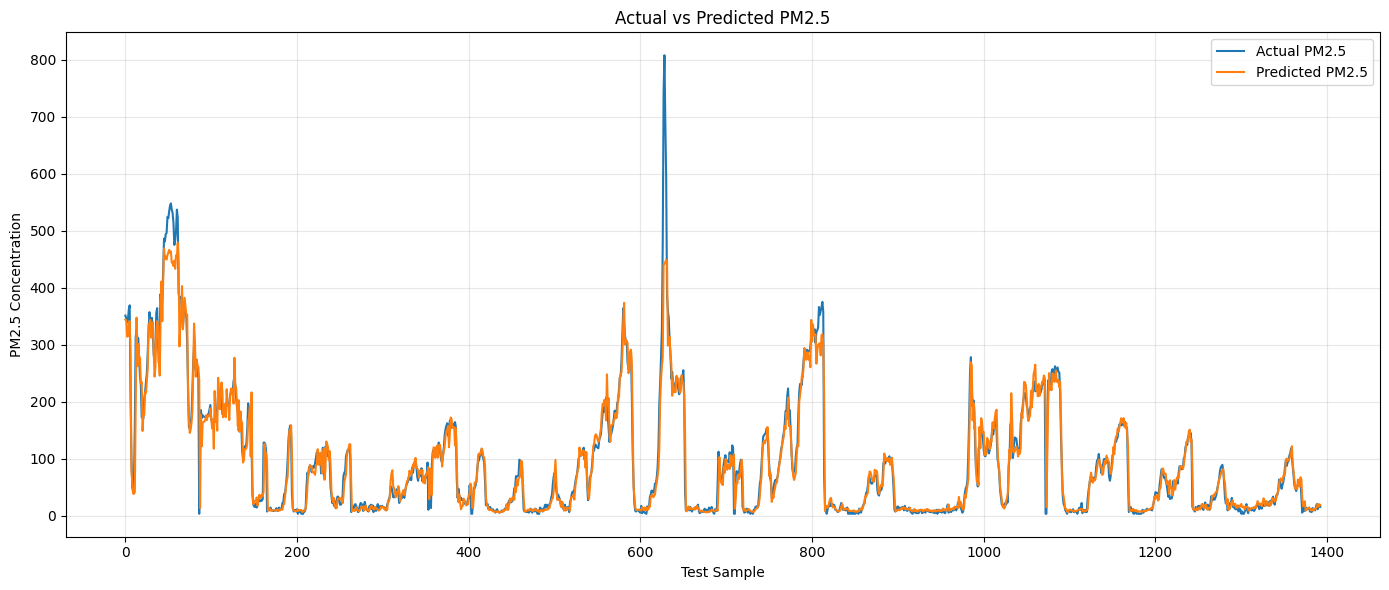

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

predictions = pd.read_csv("/content/PM25_Final_Predictions.csv")

plt.figure(figsize=(14, 6))

plt.plot(
    predictions["Actual_PM2.5"].values,
    label="Actual PM2.5",
    linewidth=1.5
)

plt.plot(
    predictions["Predicted_PM2.5"].values,
    label="Predicted PM2.5",
    linewidth=1.5
)

plt.xlabel("Test Sample")
plt.ylabel("PM2.5 Concentration")
plt.title("Actual vs Predicted PM2.5")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/Actual_vs_Predicted_PM25.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
import pandas as pd
import numpy as np

predictions = pd.read_csv("/content/PM25_Final_Predictions.csv")

# Calculate absolute error
predictions["Absolute_Error"] = abs(predictions["Error"])

print("Total predictions:", len(predictions))

print("\nMean Absolute Error:")
print(predictions["Absolute_Error"].mean())

print("\nMaximum Absolute Error:")
print(predictions["Absolute_Error"].max())

print("\nMinimum Absolute Error:")
print(predictions["Absolute_Error"].min())

print("\nTop 10 largest prediction errors:")
display(
    predictions.sort_values(
        by="Absolute_Error",
        ascending=False
    ).head(10)
)

Total predictions: 1393

Mean Absolute Error:
13.044463821734274

Maximum Absolute Error:
366.4984130859375

Minimum Absolute Error:
0.0042128562927246

Top 10 largest prediction errors:


,Actual_PM2.5,Predicted_PM2.5,Error,Absolute_Error
628,808.0,441.501600,366.498413,366.498413
627,743.0,440.097470,302.902527,302.902527
629,691.0,444.948200,246.051788,246.051788
86,3.0,237.648100,-234.648102,234.648102
626,478.0,277.285030,200.714966,200.714966
1072,3.0,194.016240,-191.016235,191.016235
630,594.0,448.629550,145.370453,145.370453
814,71.0,213.675030,-142.675034,142.675034
11,161.0,41.284344,119.715656,119.715656
87,132.0,13.240358,118.759642,118.759642


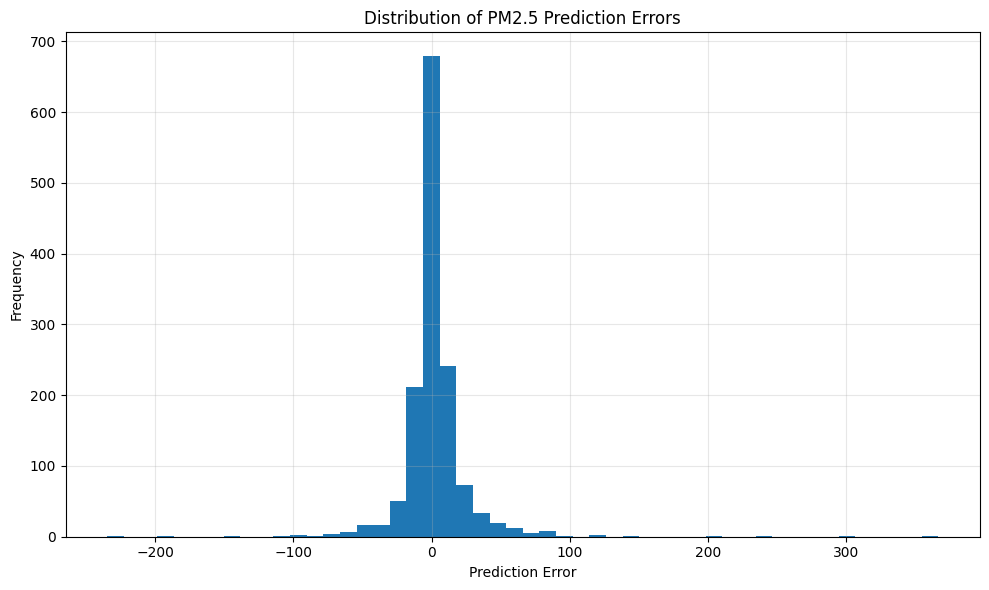

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    predictions["Error"],
    bins=50
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Prediction Errors")
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/PM25_Error_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
import os

print(
    "Error distribution graph saved:",
    os.path.exists("/content/PM25_Error_Distribution.png")
)

Error distribution graph saved: True


In [88]:
history_single
history_multi

In [89]:
print("Checking training history variables...")

variables_to_check = [
    "history_single",
    "history_multi",
    "single_history",
    "multi_history",
    "history"
]

for var in variables_to_check:
    if var in globals():
        print("FOUND:", var)
    else:
        print("Not found:", var)

Checking training history variables...
FOUND: history_single
FOUND: history_multi
Not found: single_history
Not found: multi_history
Not found: history


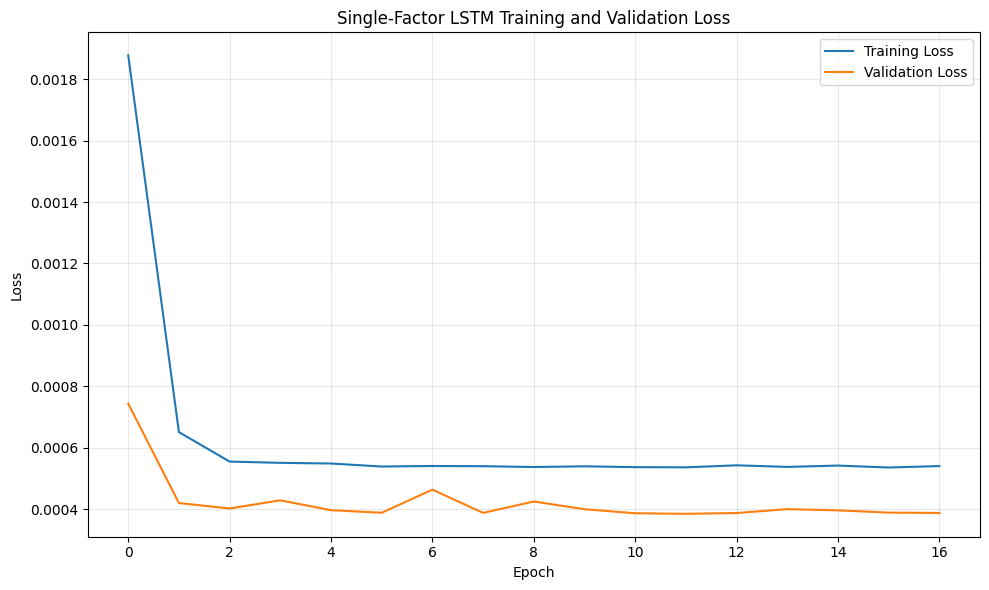

In [90]:
import matplotlib.pyplot as plt

# -----------------------------
# Single-Factor LSTM Loss
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    history_single.history["loss"],
    label="Training Loss"
)

if "val_loss" in history_single.history:
    plt.plot(
        history_single.history["val_loss"],
        label="Validation Loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Single-Factor LSTM Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/Single_Factor_LSTM_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

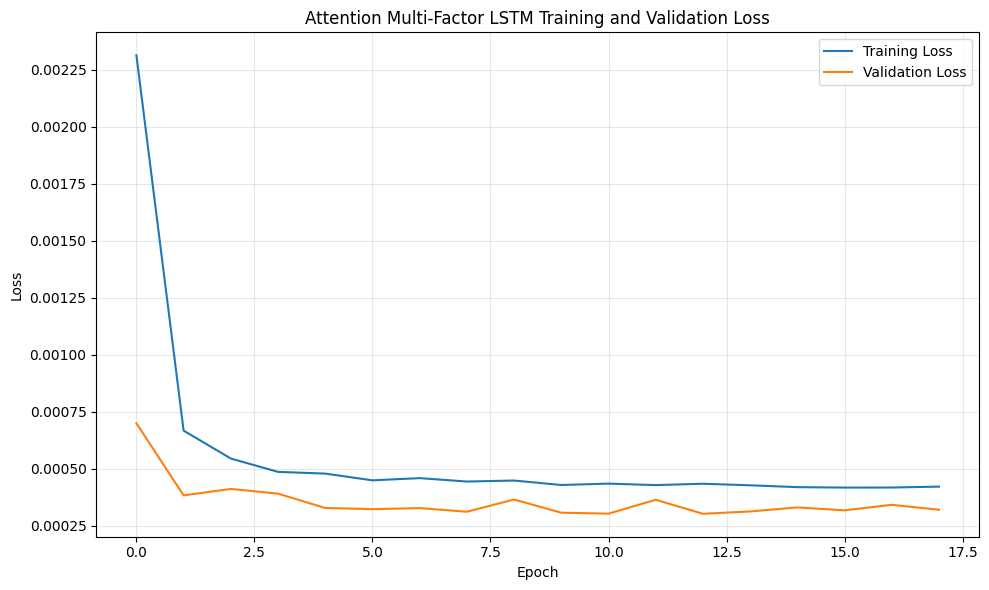

In [91]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_multi.history["loss"],
    label="Training Loss"
)

if "val_loss" in history_multi.history:
    plt.plot(
        history_multi.history["val_loss"],
        label="Validation Loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Attention Multi-Factor LSTM Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "/content/Attention_Multi_Factor_LSTM_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
import os

files = [
    "/content/Single_Factor_LSTM_Loss.png",
    "/content/Attention_Multi_Factor_LSTM_Loss.png"
]

for file in files:
    print(os.path.basename(file), "→", os.path.exists(file))

Single_Factor_LSTM_Loss.png → True
Attention_Multi_Factor_LSTM_Loss.png → True


In [93]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = pd.read_csv("/content/Model_Comparison_Metrics.csv")

# Remove unwanted index column if present
if "Unnamed: 0" in metrics.columns:
    metrics = metrics.drop(columns=["Unnamed: 0"])

print(metrics)

        RMSE        MAE   MAPE (%)        R2        IA
0  17.940963  10.370430  34.560089  0.955071  0.988187
1  16.140752   9.894123  28.744858  0.963635  0.990758
2  26.782058  13.044464  45.296024  0.939225  0.983336


In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# Load metrics
metrics = pd.read_csv("/content/Model_Comparison_Metrics.csv")

print("Original columns:")
print(metrics.columns.tolist())

print("\nOriginal data:")
display(metrics)

Original columns:
['Unnamed: 0', 'RMSE', 'MAE', 'MAPE (%)', 'R2', 'IA']

Original data:


,Unnamed: 0,RMSE,MAE,MAPE (%),R2,IA
0,Single-Factor LSTM,17.940963,10.370430,34.560089,0.955071,0.988187
1,Attention Multi-Factor LSTM,16.140752,9.894123,28.744858,0.963635,0.990758
2,Integrated Dual LSTM + XGBoost,26.782058,13.044464,45.296024,0.939225,0.983336


In [98]:
# Rename the first column to Model
metrics = metrics.rename(columns={
    "Unnamed: 0": "Model"
})

print("Updated columns:")
print(metrics.columns.tolist())

display(metrics)

Updated columns:
['Model', 'RMSE', 'MAE', 'MAPE (%)', 'R2', 'IA']


,Model,RMSE,MAE,MAPE (%),R2,IA
0,Single-Factor LSTM,17.940963,10.370430,34.560089,0.955071,0.988187
1,Attention Multi-Factor LSTM,16.140752,9.894123,28.744858,0.963635,0.990758
2,Integrated Dual LSTM + XGBoost,26.782058,13.044464,45.296024,0.939225,0.983336


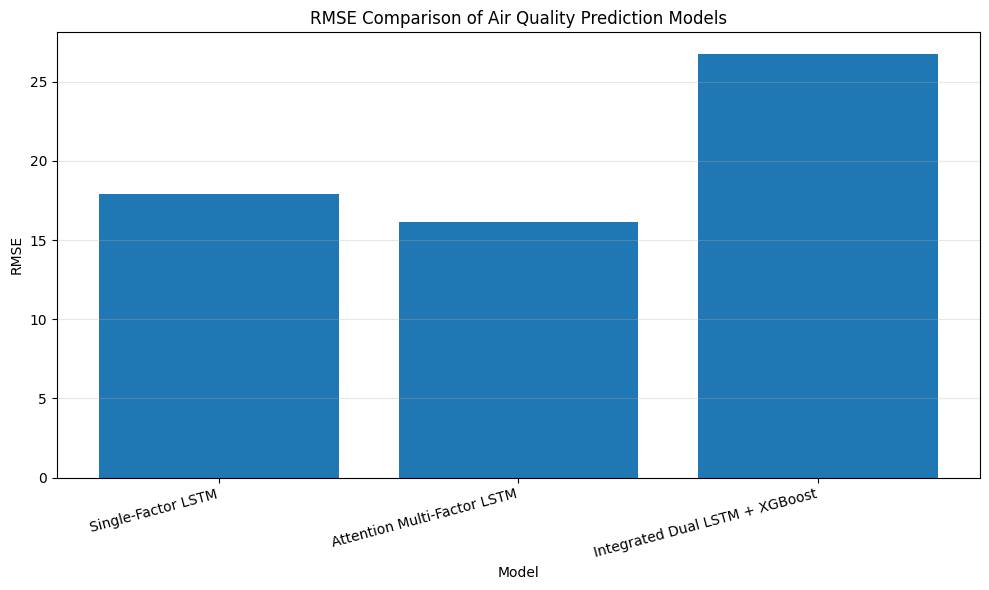

In [99]:
plt.figure(figsize=(10, 6))

plt.bar(
    metrics["Model"],
    metrics["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Air Quality Prediction Models")

plt.xticks(
    rotation=15,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "/content/RMSE_Model_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
import os

print(
    "RMSE comparison graph saved:",
    os.path.exists("/content/RMSE_Model_Comparison.png")
)

RMSE comparison graph saved: True


In [101]:
import os
import shutil

# Create project folders
folders = [
    "/content/Air_Quality_Dual_LSTM",
    "/content/Air_Quality_Dual_LSTM/models",
    "/content/Air_Quality_Dual_LSTM/results",
    "/content/Air_Quality_Dual_LSTM/graphs",
    "/content/Air_Quality_Dual_LSTM/dataset"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

# -------------------------
# Copy model files
# -------------------------
model_files = [
    "/content/Single_Factor_LSTM.keras",
    "/content/Multi_Factor_Attention_LSTM.keras",
    "/content/XGBoost_Integrator.json"
]

for file in model_files:
    if os.path.exists(file):
        shutil.copy2(
            file,
            "/content/Air_Quality_Dual_LSTM/models/"
        )
        print("Copied:", os.path.basename(file))

# -------------------------
# Copy result files
# -------------------------
result_files = [
    "/content/PM25_Final_Predictions.csv",
    "/content/Model_Comparison_Metrics.csv"
]

for file in result_files:
    if os.path.exists(file):
        shutil.copy2(
            file,
            "/content/Air_Quality_Dual_LSTM/results/"
        )
        print("Copied:", os.path.basename(file))

# -------------------------
# Copy graphs
# -------------------------
graph_files = [
    "/content/Actual_vs_Predicted_PM25.png",
    "/content/PM25_Error_Distribution.png",
    "/content/Single_Factor_LSTM_Loss.png",
    "/content/Attention_Multi_Factor_LSTM_Loss.png",
    "/content/RMSE_Model_Comparison.png"
]

for file in graph_files:
    if os.path.exists(file):
        shutil.copy2(
            file,
            "/content/Air_Quality_Dual_LSTM/graphs/"
        )
        print("Copied:", os.path.basename(file))

print("\nSTEP 55 completed successfully.")

Project folders created successfully.
Copied: Single_Factor_LSTM.keras
Copied: Multi_Factor_Attention_LSTM.keras
Copied: XGBoost_Integrator.json
Copied: PM25_Final_Predictions.csv
Copied: Model_Comparison_Metrics.csv
Copied: Actual_vs_Predicted_PM25.png
Copied: PM25_Error_Distribution.png
Copied: Single_Factor_LSTM_Loss.png
Copied: Attention_Multi_Factor_LSTM_Loss.png
Copied: RMSE_Model_Comparison.png

STEP 55 completed successfully.


In [102]:
import os

project_path = "/content/Air_Quality_Dual_LSTM"

for root, dirs, files in os.walk(project_path):
    level = root.replace(project_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

Air_Quality_Dual_LSTM/
    models/
        XGBoost_Integrator.json
        Multi_Factor_Attention_LSTM.keras
        Single_Factor_LSTM.keras
    dataset/
    graphs/
        Single_Factor_LSTM_Loss.png
        PM25_Error_Distribution.png
        Attention_Multi_Factor_LSTM_Loss.png
        Actual_vs_Predicted_PM25.png
        RMSE_Model_Comparison.png
    results/
        Model_Comparison_Metrics.csv
        PM25_Final_Predictions.csv


In [103]:
import os

project_path = "/content/Air_Quality_Dual_LSTM"

print("File sizes:\n")

for root, dirs, files in os.walk(project_path):
    for file in files:
        path = os.path.join(root, file)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{file:45s} {size_mb:.2f} MB")

File sizes:

XGBoost_Integrator.json                       1.51 MB
Multi_Factor_Attention_LSTM.keras             1.22 MB
Single_Factor_LSTM.keras                      0.61 MB
Single_Factor_LSTM_Loss.png                   0.15 MB
PM25_Error_Distribution.png                   0.08 MB
Attention_Multi_Factor_LSTM_Loss.png          0.16 MB
Actual_vs_Predicted_PM25.png                  0.41 MB
RMSE_Model_Comparison.png                     0.14 MB
Model_Comparison_Metrics.csv                  0.00 MB
PM25_Final_Predictions.csv                    0.05 MB


In [106]:
from pathlib import Path

readme = """# Air Quality Prediction Based on Integrated Dual LSTM Model

## Project Overview

This project implements an air quality prediction system based on the Integrated Dual LSTM approach described in the reference research paper.

The implementation uses the Beijing Multi-Site Air-Quality dataset and predicts PM2.5 concentration.

## Methodology

1. Data preprocessing
2. Missing-value handling
3. Feature preparation
4. Data normalization
5. 48-hour historical input sequence
6. Single-Factor LSTM
7. Attention Multi-Factor LSTM
8. XGBoost integration
9. PM2.5 prediction
10. Model evaluation

## Models

### Single-Factor LSTM

Uses historical PM2.5 information to learn temporal patterns.

### Attention Multi-Factor LSTM

Uses multiple air-quality and meteorological factors with an attention mechanism.

### XGBoost Integration

Combines the LSTM model outputs to produce the final PM2.5 prediction.

## Evaluation Metrics

- RMSE
- MAE
- MAPE
- R2
- Index of Agreement (IA)

## Experimental Results

The experiment generated 1,393 PM2.5 test predictions.

| Model | RMSE | MAE | MAPE (%) | R2 | IA |
|---|---:|---:|---:|---:|---:|
| Single-Factor LSTM | 17.941 | 10.370 | 34.560 | 0.9551 | 0.9882 |
| Attention Multi-Factor LSTM | 16.141 | 9.894 | 28.745 | 0.9636 | 0.9908 |
| Integrated Dual LSTM + XGBoost | 26.782 | 13.044 | 45.296 | 0.9392 | 0.9833 |

## Results

The prediction results generally follow the variation of the actual PM2.5 values. Larger errors occur during some extreme PM2.5 concentration events.

## Project Structure

Air_Quality_Dual_LSTM/

    models/
        Single_Factor_LSTM.keras
        Multi_Factor_Attention_LSTM.keras
        XGBoost_Integrator.json

    results/
        PM25_Final_Predictions.csv
        Model_Comparison_Metrics.csv

    graphs/
        Actual_vs_Predicted_PM25.png
        PM25_Error_Distribution.png
        Single_Factor_LSTM_Loss.png
        Attention_Multi_Factor_LSTM_Loss.png
        RMSE_Model_Comparison.png

## Reference Paper

Chen, H., Guan, M., and Li, H. (2021).
Air Quality Prediction Based on Integrated Dual LSTM Model.
IEEE Access.

## Note

This project is an implementation of the research approach using a publicly available Beijing multi-site air-quality dataset. The experimental results are independently generated and should not be considered a reproduction of the numerical results reported in the original paper.
"""

readme_path = "/content/Air_Quality_Dual_LSTM/README.md"

Path(readme_path).write_text(readme, encoding="utf-8")

print("README.md created successfully.")
print("Location:", readme_path)

README.md created successfully.
Location: /content/Air_Quality_Dual_LSTM/README.md
